# Model Evaluation & Comparison
This notebook provides a comprehensive evaluation of all trained models. We compare all variants, analyze per-class performance, generate ROC curves, and select the final production model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import shutil
from pathlib import Path

import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve, auc,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.preprocessing import label_binarize

2026-03-04 20:07:04.881525: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 20:07:04.930503: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-04 20:07:15.071805: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
PROJECT_ROOT = Path("../").resolve()
DATA_DIR = PROJECT_ROOT / "data"
ORGANIZED_DIR = DATA_DIR / "organized"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"
FINAL_MODELS_DIR = MODELS_DIR / "final"
FINAL_MODELS_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 256
BATCH_SIZE = 64
NUM_CLASSES = 8
CLASS_NAMES = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']

## 1. Load Test Set

In [3]:
test_ds = keras.utils.image_dataset_from_directory(
    ORGANIZED_DIR / "test",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
).prefetch(tf.data.AUTOTUNE)

Found 1503 files belonging to 7 classes.


I0000 00:00:1772654841.446829  559505 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13685 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


## 2. Load All Available Trained Models

In [4]:
# Mapping: descriptive name -> model file path
model_paths = {
    "Unbalanced + Unsegmented"    : MODELS_DIR / "baseline_unbalanced"  / "final_best.h5",
    "Weighted + Unsegmented"      : MODELS_DIR / "class_weighted"        / "final_best.h5",
    "Segmented + Unbalanced"      : MODELS_DIR / "segmented_unbalanced"  / "final.keras",
    "Segmented + Weighted"        : MODELS_DIR / "segmented_weighted"    / "final.keras",
    "Balanced (CGAN) + Unsegmented": MODELS_DIR / "balanced_cgan"        / "final.keras",
    # "Tuned Final"                 : MODELS_DIR / "tuned"                 / "tuned_final.keras",
}

for name, path in model_paths.items():
    status = "found" if path.exists() else "missing"
    print(f"  [{status}] {name}")

  [found] Unbalanced + Unsegmented
  [found] Weighted + Unsegmented
  [found] Segmented + Unbalanced
  [found] Segmented + Weighted
  [found] Balanced (CGAN) + Unsegmented


In [5]:
def predict_model(model, test_ds):
    """Return y_true, y_pred (integers) and y_prob (class probabilities)."""
    y_true, y_pred, y_prob = [], [], []
    for imgs, labels in test_ds:
        probs = model.predict(imgs, verbose=0)
        y_prob.extend(probs)
        y_pred.extend(np.argmax(probs, axis=1))
        y_true.extend(labels.numpy())
    return np.array(y_true), np.array(y_pred), np.array(y_prob)

In [6]:
all_results = {}

for model_name, path in model_paths.items():
    if not path.exists():
        print(f"Skipping {model_name} (model file not found)")
        continue

    print(f"Evaluating: {model_name}")
    model = keras.models.load_model(str(path))
    y_true, y_pred, y_prob = predict_model(model, test_ds)

    all_results[model_name] = {
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "accuracy":         float(accuracy_score(y_true, y_pred)),
        "macro_f1":         float(f1_score(y_true, y_pred, average='macro')),
        "weighted_f1":      float(f1_score(y_true, y_pred, average='weighted')),
        "macro_precision":  float(precision_score(y_true, y_pred, average='macro')),
        "macro_recall":     float(recall_score(y_true, y_pred, average='macro')),
    }
    print(f"  Accuracy: {all_results[model_name]['accuracy']:.4f}  Macro F1: {all_results[model_name]['macro_f1']:.4f}")

Evaluating: Unbalanced + Unsegmented


2026-03-04 20:07:22.088621: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
2026-03-04 20:07:27.587378: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-03-04 20:07:44.991769: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  Accuracy: 0.7345  Macro F1: 0.4229
Evaluating: Weighted + Unsegmented


2026-03-04 20:07:56.204236: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  Accuracy: 0.6208  Macro F1: 0.4159
Evaluating: Segmented + Unbalanced


.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


  Accuracy: 0.5742  Macro F1: 0.1494
Evaluating: Segmented + Weighted


2026-03-04 20:08:18.573955: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


  Accuracy: 0.2954  Macro F1: 0.1055
Evaluating: Balanced (CGAN) + Unsegmented
  Accuracy: 0.7219  Macro F1: 0.3594


## 3. Overall Comparison Table

In [7]:
comparison_rows = []
for name, res in all_results.items():
    comparison_rows.append({
        "Model":             name,
        "Accuracy":          res['accuracy'],
        "Macro_F1":          res['macro_f1'],
        "Weighted_F1":       res['weighted_f1'],
        "Macro_Precision":   res['macro_precision'],
        "Macro_Recall":      res['macro_recall'],
    })

comp_df = pd.DataFrame(comparison_rows).sort_values("Macro_F1", ascending=False)
print(comp_df.to_string(index=False))

                        Model  Accuracy  Macro_F1  Weighted_F1  Macro_Precision  Macro_Recall
     Unbalanced + Unsegmented  0.734531  0.422884     0.712259         0.543517      0.399386
       Weighted + Unsegmented  0.620758  0.415941     0.661712         0.428254      0.543155
Balanced (CGAN) + Unsegmented  0.721890  0.359367     0.689023         0.478838      0.322101
       Segmented + Unbalanced  0.574185  0.149414     0.532018         0.163635      0.194982
         Segmented + Weighted  0.295409  0.105464     0.373191         0.190053      0.211467


## 4. Per-Class Recall Analysis
Macro recall treats all classes equally. We compare per-class recall across models — especially important for minority malignant classes (MEL, SCC) where missed detections have clinical consequences.

In [8]:
from sklearn.metrics import recall_score

recall_rows = []
for name, res in all_results.items():
    per_class = recall_score(res['y_true'], res['y_pred'], average=None)
    row = {"Model": name}
    row.update({cls: round(recall, 3) for cls, recall in zip(CLASS_NAMES, per_class)})
    recall_rows.append(row)

recall_df = pd.DataFrame(recall_rows)
print("Per-class Recall:")
print(recall_df.to_string(index=False))

Per-class Recall:
                        Model  AKIEC   BCC   BKL    DF   MEL    NV  VASC
     Unbalanced + Unsegmented  0.102 0.221 0.406 0.294 0.335 0.937 0.500
       Weighted + Unsegmented  0.327 0.338 0.364 0.706 0.491 0.714 0.864
       Segmented + Unbalanced  0.000 0.013 0.000 0.000 0.114 0.829 0.409
         Segmented + Weighted  0.000 0.000 0.018 0.176 0.060 0.408 0.818
Balanced (CGAN) + Unsegmented  0.122 0.156 0.333 0.118 0.305 0.947 0.273


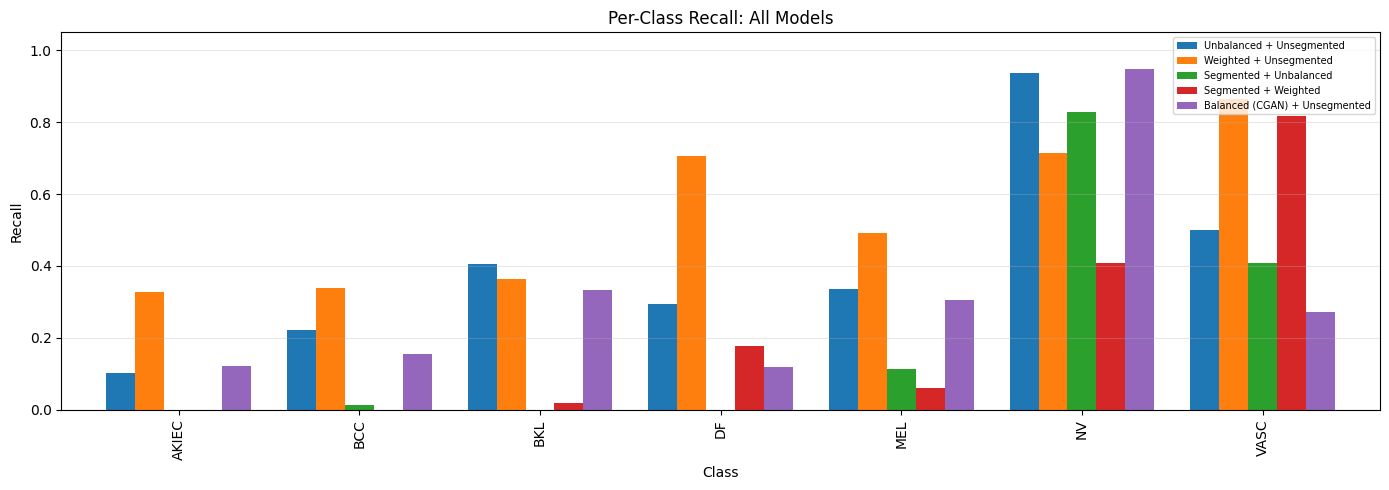

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

recall_plot = recall_df.set_index('Model')[CLASS_NAMES]
recall_plot.T.plot(kind='bar', ax=ax, width=0.8)

ax.set_xlabel('Class')
ax.set_ylabel('Recall')
ax.set_title('Per-Class Recall: All Models')
ax.set_ylim(0, 1.05)
ax.legend(loc='upper right', fontsize=7)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "per_class_recall_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Confusion Matrix — Best Model

Best model: Unbalanced + Unsegmented


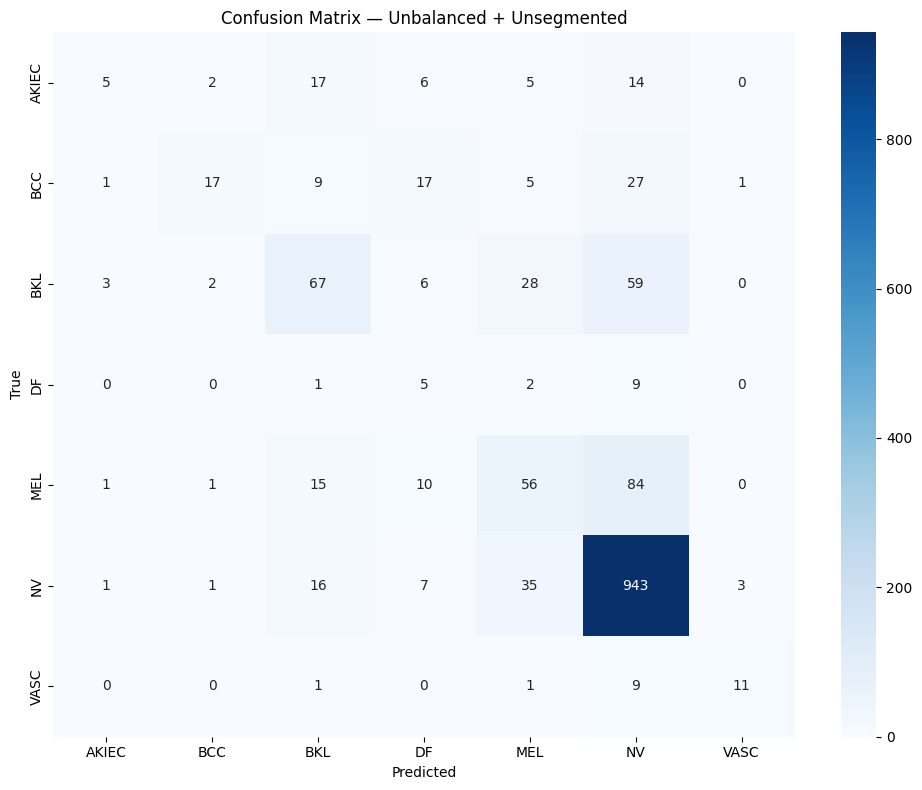

In [10]:
best_model_name = comp_df.iloc[0]['Model']
best_res = all_results[best_model_name]

print(f"Best model: {best_model_name}")

cm = confusion_matrix(best_res['y_true'], best_res['y_pred'])

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.savefig(RESULTS_DIR / "best_model_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. ROC Curves (One-vs-Rest)
ROC curves allow us to assess discriminative performance independently of the classification threshold. We compute AUC for each class vs. rest.

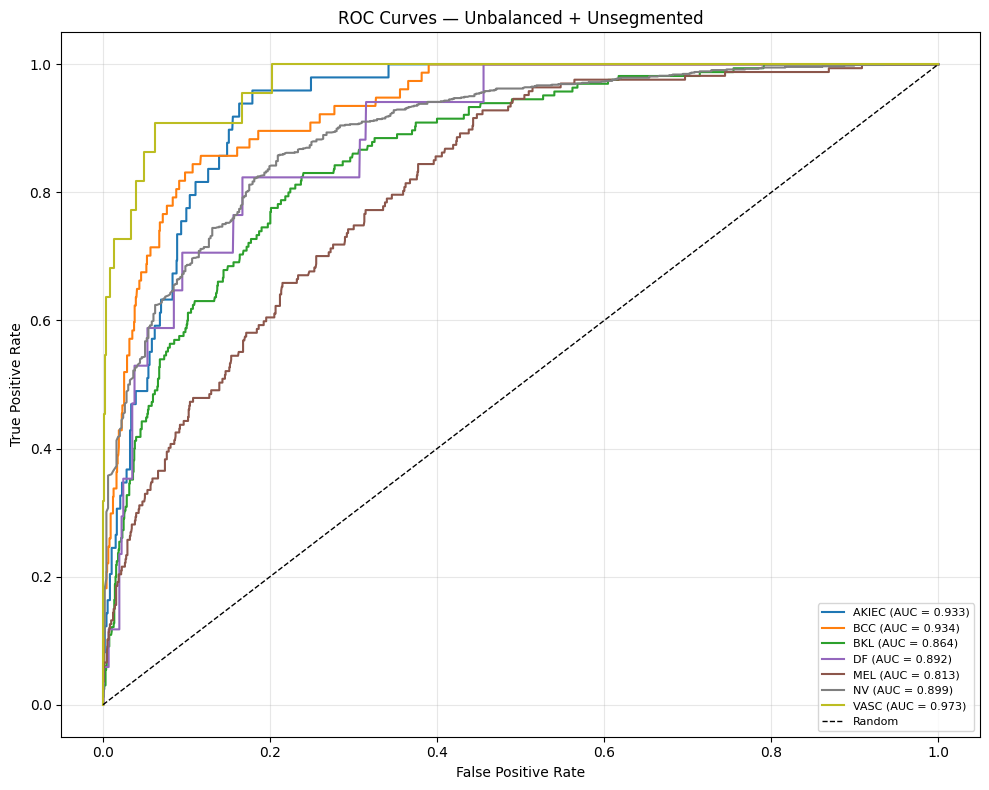

In [11]:
y_true_bin = label_binarize(best_res['y_true'], classes=list(range(NUM_CLASSES)))
y_prob = best_res['y_prob']

fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=1.5, label=f'{cls_name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC Curves — {best_model_name}')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "best_model_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# Per-class AUC table
auc_rows = []
for i, cls_name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    auc_rows.append({"Class": cls_name, "AUC": round(roc_auc, 4)})

auc_df = pd.DataFrame(auc_rows).sort_values("AUC", ascending=False)
print("Per-class AUC (best model):")
print(auc_df.to_string(index=False))

Per-class AUC (best model):
Class    AUC
 VASC 0.9731
  BCC 0.9343
AKIEC 0.9329
   NV 0.8985
   DF 0.8922
  BKL 0.8644
  MEL 0.8135


## 7. Detailed Report on Best Model

In [13]:
print(f"Detailed Classification Report — {best_model_name}:")
print(classification_report(best_res['y_true'], best_res['y_pred'], target_names=CLASS_NAMES))

Detailed Classification Report — Unbalanced + Unsegmented:
              precision    recall  f1-score   support

       AKIEC       0.45      0.10      0.17        49
         BCC       0.74      0.22      0.34        77
         BKL       0.53      0.41      0.46       165
          DF       0.10      0.29      0.15        17
         MEL       0.42      0.34      0.37       167
          NV       0.82      0.94      0.88      1006
        VASC       0.73      0.50      0.59        22

    accuracy                           0.73      1503
   macro avg       0.54      0.40      0.42      1503
weighted avg       0.72      0.73      0.71      1503



## 8. Select and Save Final Production Model

In [14]:
best_path = model_paths.get(best_model_name)

if best_path:
    
    if best_path.suffix not in [".h5", ".keras"]:
        
        h5_path = best_path.with_suffix(".h5")
        keras_path = best_path.with_suffix(".keras")

        if h5_path.exists():
            best_path = h5_path
        elif keras_path.exists():
            best_path = keras_path
        else:
            best_path = None

    if best_path and best_path.exists():
        final_dest = FINAL_MODELS_DIR / f"best_model{best_path.suffix}"
        shutil.copy2(best_path, final_dest)
        # print(f"Best model copied to: {final_dest}")
    else:
        print("Best model file not found — please retrain.")

else:
    print("Best model not found in model_paths.")

In [15]:
final_summary = {
    "selected_model":   best_model_name,
    "test_accuracy":    float(best_res['accuracy']),
    "macro_f1":         float(best_res['macro_f1']),
    "weighted_f1":      float(best_res['weighted_f1']),
    "macro_precision":  float(best_res['macro_precision']),
    "macro_recall":     float(best_res['macro_recall']),
    "per_class_auc":    {row['Class']: row['AUC'] for _, row in auc_df.iterrows()},
    "all_model_metrics": [
        {
            "model":          name,
            "accuracy":       res['accuracy'],
            "macro_f1":       res['macro_f1'],
            "weighted_f1":    res['weighted_f1'],
        }
        for name, res in all_results.items()
    ]
}

with open(RESULTS_DIR / "final_evaluation_summary.json", "w") as f:
    json.dump(final_summary, f, indent=2)

print("Final evaluation summary saved.")
print(f"\nSelected model: {best_model_name}")
print(f"  Accuracy:    {best_res['accuracy']:.4f}")
print(f"  Macro F1:    {best_res['macro_f1']:.4f}")

Final evaluation summary saved.

Selected model: Unbalanced + Unsegmented
  Accuracy:    0.7345
  Macro F1:    0.4229


In [16]:
# Save comparison CSV
comp_df.to_csv(RESULTS_DIR / "final_model_comparison.csv", index=False)
recall_df.to_csv(RESULTS_DIR / "per_class_recall_all_models.csv", index=False)
auc_df.to_csv(RESULTS_DIR   / "per_class_auc_best_model.csv", index=False)

print("All evaluation tables saved.")

All evaluation tables saved.
